In [1]:
from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd().parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

print(PROJECT_ROOT)

o:\Hackthons\KrishiOS\ai


In [3]:
import torch
import numpy as np
import matplotlib.pyplot as plt

from PIL import Image

from torchvision import transforms
from torchvision.datasets import ImageFolder

from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.image import show_cam_on_image

from configs.config import *

from training.model import build_model
print("✅ Libraries Loaded")

✅ Libraries Loaded


In [4]:
model = build_model(NUM_CLASSES)

checkpoint = torch.load(
    PROJECT_ROOT / "models" / "best_model.pth",
    map_location=DEVICE,
)

model.load_state_dict(checkpoint["model_state_dict"])
model.to(DEVICE)
model.eval()

print("✅ Model Loaded")

✅ Model Loaded


In [12]:
for param in model.features.parameters():
    param.requires_grad = True

model.eval()

print("✅ Gradients enabled for Grad-CAM")

✅ Gradients enabled for Grad-CAM


In [13]:
dataset = ImageFolder(TRAIN_DIR)

class_names = dataset.classes

sample_dir = TRAIN_DIR / class_names[0]

image_path = list(sample_dir.glob("*"))[0]

print(image_path)

O:\Hackthons\KrishiOS\ai\dataset\PlantVillage\train\Apple___Apple_scab\01a66316-0e98-4d3b-a56f-d78752cd043f___FREC_Scab 3003.JPG


In [16]:
transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225],
    ),
])

image = Image.open(image_path).convert("RGB")

rgb_image = np.array(
    image.resize((IMAGE_SIZE, IMAGE_SIZE))
)

input_tensor = transform(image).unsqueeze(0)

input_tensor = input_tensor.to(DEVICE)

input_tensor.requires_grad_(True)

tensor([[[[ 0.1597,  0.0912,  0.0569,  ..., -0.0287, -0.0458, -0.0287],
          [ 0.1083,  0.1254,  0.1254,  ..., -0.0287, -0.0458, -0.0287],
          [ 0.0912,  0.1597,  0.1939,  ..., -0.0287, -0.0287, -0.0116],
          ...,
          [-1.2617, -1.2617, -1.2788,  ..., -0.6281, -0.6109, -0.5767],
          [-1.3130, -1.3130, -1.3130,  ..., -0.6281, -0.6109, -0.5938],
          [-1.3644, -1.3644, -1.3815,  ..., -0.6452, -0.6109, -0.6109]],

         [[ 0.1702,  0.1001,  0.0651,  ...,  0.0126, -0.0049,  0.0126],
          [ 0.1176,  0.1352,  0.1352,  ...,  0.0126, -0.0049,  0.0126],
          [ 0.1001,  0.1702,  0.2052,  ...,  0.0126,  0.0126,  0.0301],
          ...,
          [-1.4405, -1.4405, -1.4580,  ..., -0.6527, -0.6352, -0.6001],
          [-1.4755, -1.4755, -1.4755,  ..., -0.6352, -0.6176, -0.6001],
          [-1.5280, -1.5280, -1.5455,  ..., -0.6527, -0.6176, -0.6176]],

         [[ 1.2805,  1.2108,  1.1759,  ...,  1.2108,  1.1934,  1.2108],
          [ 1.2282,  1.2457,  

In [17]:
with torch.no_grad():

    outputs = model(input_tensor)

    probabilities = torch.softmax(outputs, dim=1)

confidence, prediction = torch.max(
    probabilities,
    dim=1,
)

print("Prediction :", class_names[prediction.item()])

print(f"Confidence : {confidence.item()*100:.2f}%")

Prediction : Apple___Apple_scab
Confidence : 99.65%


In [18]:
# Last convolution layer in EfficientNet-B0

target_layers = [
    model.features[8][0]
]

cam = GradCAM(
    model=model,
    target_layers=target_layers,
)

In [19]:
grayscale_cam = cam(
    input_tensor=input_tensor
)[0]

visualization = show_cam_on_image(
    rgb_image.astype(np.float32) / 255.0,
    grayscale_cam,
    use_rgb=True,
)

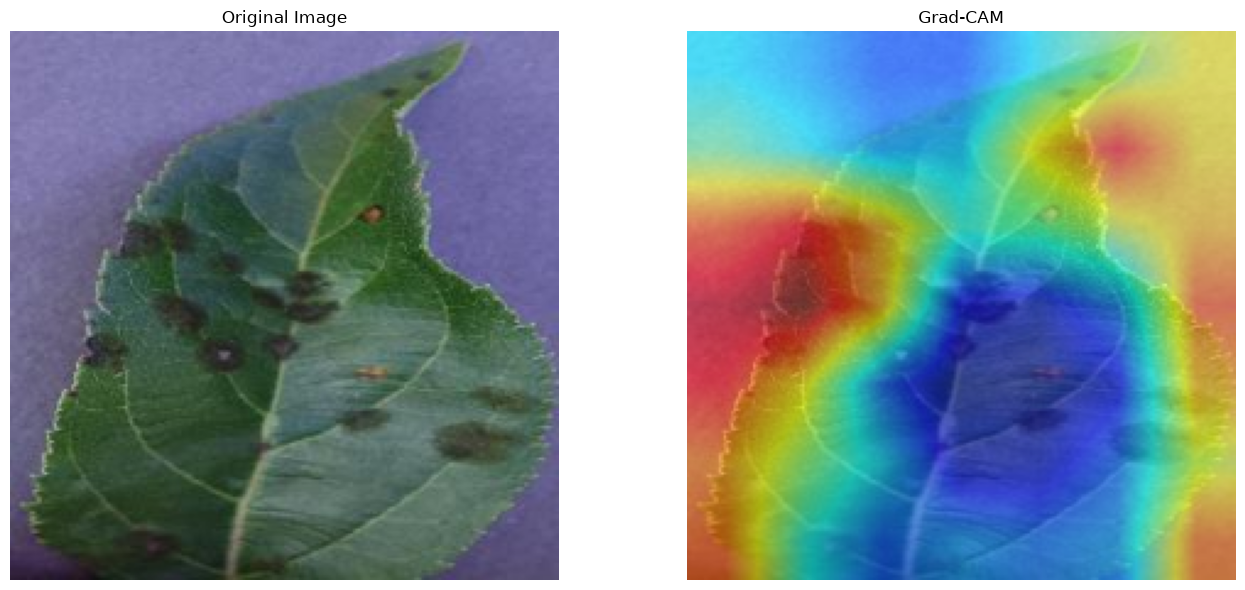

In [20]:
fig, axes = plt.subplots(
    1,
    2,
    figsize=(14,6),
)

axes[0].imshow(rgb_image)

axes[0].set_title("Original Image")

axes[0].axis("off")

axes[1].imshow(visualization)

axes[1].set_title("Grad-CAM")

axes[1].axis("off")

plt.tight_layout()

plt.show()

In [26]:
output_path = PROJECT_ROOT / "outputs" / "gradcam_result.png"

plt.imsave(
    output_path,
    visualization,
)

print("✅ Grad-CAM saved successfully")

✅ Grad-CAM saved successfully


In [27]:
print("=" * 60)
print("Grad-CAM Completed")
print()

print(f"Prediction : {class_names[prediction.item()]}")
print(f"Confidence : {confidence.item() * 100:.2f}%")

print()
print("Saved to:")
print(output_path)

Grad-CAM Completed

Prediction : Apple___Apple_scab
Confidence : 99.65%

Saved to:
O:\Hackthons\KrishiOS\ai\outputs\gradcam_result.png
